# Setup (run these first)

In [2]:
using DifferentialEquations, Parameters
using CairoMakie

## Plotting Functions

In [3]:
function blank_axis(; 
    xcolor     = :blue,
    ycolor     = :black,
    xlabel     = "",
    ylabel     = "",
    xticks     = nothing,
    yticks     = nothing,
    xaxiswidth = 2,
    yaxiswidth = 2,
    xtickwidth = 2,
    ytickwidth = 2,
    xlabelsize=20,
    ylabelsize=20,
    size       = (500, 500),
    title      =  "",
    padding    = 12
)

    fig = Figure(size = size,figure_padding = (padding, padding, padding, padding))

    ax = Axis(fig[1, 1]; 
        xlabel = xlabel,
        ylabel = ylabel,
        title = title,

        # Tick and label colors
        xticklabelcolor = xcolor,
        yticklabelcolor = ycolor,
        xtickcolor = xcolor,
        ytickcolor = ycolor,
        xlabelcolor = xcolor,
        ylabelcolor = ycolor,

        #label sizes
        xlabelsize=xlabelsize,
        ylabelsize=ylabelsize,

        # Tick widths
        xtickwidth = xtickwidth,
        ytickwidth = ytickwidth,
        xticksize = 8,
        yticksize = 8,

        # Grid off
        xgridvisible = false,
        ygridvisible = false,

        # Spine colors and widths
        bottomspinecolor = xcolor,
        leftspinecolor = ycolor,
        spinewidth = yaxiswidth,

        # Optional: hide top and right spines
        topspinevisible = false,
        rightspinevisible = false,
    )

    if xticks !== nothing
        ax.xticks = xticks
    end
    if yticks !== nothing
        ax.yticks = yticks
    end

    return fig, ax
end

function blank_axis_grid(rows::Int, cols::Int;
    titles     = nothing,          # nothing | Vector | Matrix
    xcolors    = :blue,            # scalar | Vector | Matrix
    ycolors    = :black,           # scalar | Vector | Matrix
    xlabels    = "",               # scalar | Vector | Matrix
    ylabels    = "",               # scalar | Vector | Matrix
    xticks     = nothing,          # scalar | Vector | Matrix
    yticks     = nothing,          # scalar | Vector | Matrix
    xlabelsize = 12,
    ylabelsize = 12,
    xaxiswidth = 1,
    yaxiswidth = 1,
    xtickwidth = 1,
    ytickwidth = 1,
    size       = (900, 600),
    padding    = 12,
    rowgap     = 12,
    colgap     = 12,
)

    fig = Figure(size = size, figure_padding = (padding, padding, padding, padding))
    rowgap!(fig.layout, rowgap)
    colgap!(fig.layout, colgap)

    # helper: broadcast scalar / vector / matrix into (rows, cols) indexing
    tocell(x, i, j) = x isa AbstractMatrix ? x[i, j] :
                      x isa AbstractVector ? x[(i-1)*cols + j] :
                      x

    axes = Matrix{Axis}(undef, rows, cols)

    for i in 1:rows, j in 1:cols
        xcolor = tocell(xcolors, i, j)
        ycolor = tocell(ycolors, i, j)

        title  = titles === nothing ? "" : tocell(titles, i, j)
        xlabel = tocell(xlabels, i, j)
        ylabel = tocell(ylabels, i, j)

        ax = Axis(fig[i, j];
            xlabel = xlabel,
            ylabel = ylabel,
            title  = title,

            xticklabelcolor = xcolor,
            yticklabelcolor = ycolor,
            xtickcolor      = xcolor,
            ytickcolor      = ycolor,
            xlabelcolor     = xcolor,
            ylabelcolor     = ycolor,

            xlabelsize      = xlabelsize,
            ylabelsize      = ylabelsize,

            xtickwidth      = xtickwidth,
            ytickwidth      = ytickwidth,
            xticksize       = 8,
            yticksize       = 8,

            xgridvisible    = false,
            ygridvisible    = false,

            bottomspinecolor = xcolor,
            leftspinecolor   = ycolor,
            spinewidth       = yaxiswidth,

            topspinevisible  = false,
            rightspinevisible = false,
        )

        # per-axis ticks (scalar/vector/matrix supported)
        xt = tocell(xticks, i, j)
        yt = tocell(yticks, i, j)
        if xt !== nothing; ax.xticks = xt; end
        if yt !== nothing; ax.yticks = yt; end

        axes[i, j] = ax
    end

    return fig, axes
end


#Define colors
betaBlue = "#4a86e8"
alphaRed = "#ff6370"
lambdaPurple = "#984ea3"
negOnly = "#f7bb7cff"  
negOnlyFaint="#f7bb7c55"
posOnly = "#9fcb8cff"
posOnlyFaint = "#9fcb8c55" 
sponPos    = "#c8e1bcff"
sponPosFaint    = "#c8e1bc55"
sponNeg    = "#fad7b3ff"
sponNegFaint = "#fad7b355"
sponBoth = "#bddaff6d"
sponBothFaint = "#bddaff55"
inducible = "#ffebb0ff"
inducibleFaint = "#ffebb055"
nodata="#00000000"

"#00000000"

## ODEs 
Define the ODEs

In [5]:
# default parameters
parameters = (
    alpha = 0.0,
    beta = 0.0,
    lambda = 0.0,
    ra = 1.0,
    rb = 1.0,
    H_strength = 1.0,
    epsilon = 0.01,
    S_sigmoid = false
)

# Original ODEs
function ODE!(du, u, p, t)

    # unpack parameters
    @unpack alpha, beta, lambda, ra, rb, H_strength, epsilon, S_sigmoid = p
    
    # more interpretable names for states (p = +, n = -)
    ApBp, ApBn, AnBp, AnBn = u

    # calculate S (mean attitude of the population) 
    if S_sigmoid
        k = -2
        x = 2 .* (ApBp + ApBn) .- 1
        S = k .* x ./  (k .- abs.(x) .+ 1)
    else
        S = ApBp + ApBn - AnBp - AnBn  
    end
    
    # since the direction of flows depends on the direction of alpha and beta, 
    # implement equations with both possible directions included, 
    # but the incorrect direction will be set to zero
    absBetaifPos = max(beta, 0)
    absBetaifNeg = max(-beta, 0)
    absAlphaifPos = max(alpha, 0)
    absAlphaifNeg = max(-alpha, 0)
    
    # probablity of random update
    randBehavProb = (1-lambda) * (1-H_strength)
    randAttProb   = (1-lambda) * (1-abs(S))
    
    # Weighted update probs
    # (note, for behavior, H always works against changing behavior, 
    #  which is why H_strength is negative in all of these equations.)
    # (note, There are no equations needed for staying in the same state, 
    #  because these updates would not show up in the equations)
    if iszero(H_strength+lambda) #avoid divide by zero issue
        W_Bntop_Ap = 0.5 
        W_Bntop_An = 0.5 
        W_Bpton_Ap = 0.5 
        W_Bpton_An = 0.5 
    else       
        W_Bntop_Ap = 0.5 + 0.5 * (-H_strength + lambda)/(H_strength+lambda)
        W_Bntop_An = 0.5 + 0.5 * (-H_strength - lambda)/(H_strength+lambda)
        W_Bpton_Ap = 0.5 + 0.5 * (-H_strength - lambda)/(H_strength+lambda)
        W_Bpton_An = 0.5 + 0.5 * (-H_strength + lambda)/(H_strength+lambda)
    end

    if iszero(abs(S)+lambda) #avoid divide by zero issue
        W_Antop_Bp = 0.5
        W_Antop_Bn = 0.5
        W_Apton_Bp = 0.5
        W_Apton_Bn = 0.5
    else
        W_Antop_Bp = 0.5 + 0.5 * (S + lambda)/(abs(S)+lambda)
        W_Antop_Bn = 0.5 + 0.5 * (S - lambda)/(abs(S)+lambda)
        W_Apton_Bp = 0.5 + 0.5 * (-S - lambda)/(abs(S)+lambda)
        W_Apton_Bn = 0.5 + 0.5 * (-S + lambda)/(abs(S)+lambda)
    end
    
    # d(ApBp)/dt
    du[1] = (rb * (absBetaifPos * ApBn - absBetaifNeg * ApBp
               + (1-abs(beta)) * (randBehavProb + (1-randBehavProb) * epsilon) * (ApBn - ApBp)/2
               + (1-abs(beta)) * (1-randBehavProb) * (1-epsilon) * (W_Bntop_Ap * ApBn - W_Bpton_Ap * ApBp))
          + ra * (absAlphaifPos * AnBp - absAlphaifNeg * ApBp
               + (1-abs(alpha)) * (randAttProb + (1-randAttProb) * epsilon) * (AnBp - ApBp)/2
               + (1-abs(alpha)) * (1-randAttProb) * (1-epsilon) * (W_Antop_Bp * AnBp - W_Apton_Bp * ApBp)))
        
    # d(ApBn)/dt
    du[2] = (rb * (absBetaifNeg * ApBp - absBetaifPos * ApBn
               + (1-abs(beta)) * (randBehavProb + (1-randBehavProb) * epsilon) * (ApBp - ApBn)/2
               + (1-abs(beta)) * (1-randBehavProb) * (1-epsilon) * (W_Bpton_Ap * ApBp - W_Bntop_Ap * ApBn))
          + ra * (absAlphaifPos * AnBn - absAlphaifNeg * ApBn
               + (1-abs(alpha)) * (randAttProb + (1-randAttProb) * epsilon) * (AnBn - ApBn)/2
               + (1-abs(alpha)) * (1-randAttProb) * (1-epsilon) * (W_Antop_Bn * AnBn - W_Apton_Bn * ApBn)))
    
    # d(AnBp)/dt
    du[3] = (rb * (absBetaifPos * AnBn - absBetaifNeg * AnBp
               + (1-abs(beta)) * (randBehavProb + (1-randBehavProb) * epsilon) * (AnBn - AnBp)/2
               + (1-abs(beta)) * (1-randBehavProb) * (1-epsilon) * (W_Bntop_An * AnBn - W_Bpton_An * AnBp)) 
          + ra * (absAlphaifNeg * ApBp - absAlphaifPos * AnBp
               + (1-abs(alpha)) * (randAttProb + (1-randAttProb) * epsilon) * (ApBp - AnBp)/2
               + (1-abs(alpha)) * (1-randAttProb) * (1-epsilon) * (W_Apton_Bp * ApBp - W_Antop_Bp * AnBp)))
 
    
    # d(AnBn)/dt
    du[4] = (rb * (absBetaifNeg * AnBp - absBetaifPos * AnBn
               + (1-abs(beta)) * (randBehavProb + (1-randBehavProb) * epsilon) * (AnBp - AnBn)/2
               + (1-abs(beta)) * (1-randBehavProb) * (1-epsilon) * (W_Bpton_An * AnBp - W_Bntop_An * AnBn))
          + ra * (absAlphaifNeg * ApBn - absAlphaifPos * AnBn
               + (1-abs(alpha)) * (randAttProb + (1-randAttProb) * epsilon) * (ApBn - AnBn)/2
               + (1-abs(alpha)) * (1-randAttProb) * (1-epsilon) * (W_Apton_Bn * ApBn - W_Antop_Bn * AnBn)))
end


#################################################################################################################################
# equivalent equations that take in the frequency of A+ and B+ instead of the frequencies of A+B+, A+B-, A-B+, and A-B- as inputs
function ODEposneg!(du, u, p, t)

    #println("----------------")
    #println(u)
    # unpack parameters
    @unpack alpha, beta, lambda, ra, rb, H_strength, epsilon, S_sigmoid = p
    
    # more interpretable names for states (p = +, n = -)
    Ap, Bp = u

    An = (1-Ap)
    Bn = (1-Bp)

    # calculate S (mean attitude of the population) 
    if S_sigmoid
        k = -2
        x = 2 .* Ap .- 1
        S = k .* x ./  (k .- abs.(x) .+ 1)
    else
        S = Ap - An  
    end

    # since the direction of flows depends on the direction of alpha and beta, 
    # implement equations with both possible directions included, 
    # but the incorrect direction will be set to zero
    absBetaifPos = max(beta, 0)
    absBetaifNeg = max(-beta, 0)
    absAlphaifPos = max(alpha, 0)
    absAlphaifNeg = max(-alpha, 0)
    
    # probablity of random update
    randBehavProb = (1-lambda) * (1-H_strength)
    randAttProb   = (1-lambda) * (1-abs(S))


    if iszero(H_strength+lambda) #avoid divide by zero issue
        lastPartB = 0.0
    else 
        lastPartB =(H_strength*(Bp-Bn) + lambda*(Ap-An))/(2*(abs(H_strength)+lambda))
    end

    if iszero(abs(S)+lambda) #avoid divide by zero issue
        lastPartA = 0.0
    else
        lastPartA = (S +lambda*(Bp-Bn))/(2*(abs(S)+lambda))
    end
    
    # d(Ap)/dt
    du[1] = ra * (absAlphaifPos * An - absAlphaifNeg * Ap
               + (1-abs(alpha)) * (An - Ap)/2
               + (1-abs(alpha)) * (1-randAttProb) * (1-epsilon) * lastPartA)
    
    # d(Bp)/dt
    du[2] = rb * (absBetaifPos * Bn - absBetaifNeg * Bp
               + (1-abs(beta)) * (Bn - Bp)/2
               + (1-abs(beta)) * (1-randBehavProb) * (1-epsilon) * lastPartB)
end
##################################################################################################################################
# wrapper for Makie streamplot
function vf(x, p)
    du = zeros(2)
    u = [x[1], x[2]]
    ODEposneg!(du, u, p, 0.0)
    return Point2f(du[1], du[2])
end;

## Timeseries
To create a specific timeseries plot, change the whichPlot to the name of the plot you'd like to generate, or create your own by setting whichPlot to "freestyle" and change the values in the "if whichPlot == "freestyle" section

If you want to use sigmoid-style Social Influence instead, set S_sigmoid = true

1...2...3...4...5...6...

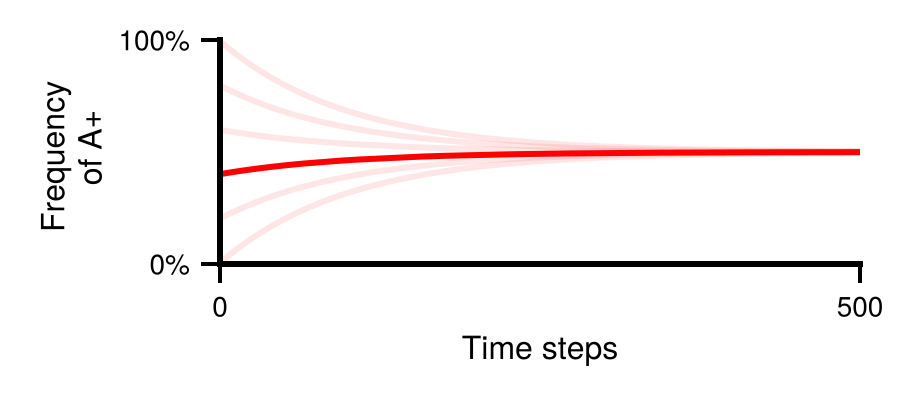

In [7]:
##############################
#     Default Parameters     
##############################
β = 0.0
α = 0.0
λ = 0.0
err = 0.01
S_sigmoid=false   # set to true if you want to use sigmoid-style (conformity biased) Social Influence

########################
# Plotting parameters   
########################

startTime=1       # Start time of the plot
plotTL = 15000    # plot time limit
lw=3              # line width
highlight = 3     # which of the simulations to plot in bold color (in order to visually highlight a single trajectory)
plotRed = true    # set to false if you want to hide attitude outcomes
plotBlue= true    # set to false if you want to hide behavior outcomes

repsEach = 1 # how many repetitions to plot from each starting state
numStartingStates = 6 # number of evenly-spaced starting states to simulate/plot
startingStateStep = 1.0/(numStartingStates-1)

###########################################################################################
#   Set whichPlot to the name of the plot you'd like to generate
#   List of options and their parameter values found in the if/elseif statements below
#
#   Want to set your own parameter values? set whichPlot = "freestyle"
#   and edit the parameters in the corresponding block ("if whichPlot == "freestyle"...")
###########################################################################################

whichPlot = "social influence only"

if whichPlot=="freestyle"

    # set your own parameter values here!
    α=0.0
    β=0.0
    λ = 0.0

    highlight = 3
    plotRed = true
    plotBlue = true
    
    titleString="α = $α β = $β λ = $λ"
    
elseif whichPlot == "habit only"
    # Fig S2A
    titleString="habit only"
    highlight=2
    plotRed=false
    plotsize=(450,200)
    plotTL = 500

elseif whichPlot=="social influence only"
    # Fig S2B
    titleString="social influence only"
    highlight=3
    plotBlue=false
    plotsize=(450,200)
    plotTL = 500
    
    
elseif whichPlot=="strong behav bias"
    # Fig S3Ai
    titleString="strong behav bias"
    β=-0.1
    highlight = 1
    plotRed=false
    
elseif whichPlot=="weak behav bias"
    # Fig S3Aii
    titleString="weak behav bias"
    β=-0.01
    highlight = 5
    plotRed=false

elseif whichPlot=="strong att bias"
    # Fig S3Bi
    titleString="strong att bias"
    β=-0.1
    highlight = 1
    plotRed=false
    
elseif whichPlot=="weak att bias"
    # Fig S3Bii
    titleString="weak att bias"
    β=-0.01
    highlight = 5
    plotRed=false

elseif whichPlot=="weak linkage"
    # Fig S3Ci
    titleString="weak linkage"
    β=-0.1
    highlight = 1
    plotRed=false
    
elseif whichPlot=="strong linkage"
    # Fig S3Cii
    titleString="strong linkage"
    β=-0.01
    highlight = 5
    plotRed=false

end

parameters = (alpha = α, beta = β, lambda = λ, ra = 1.0, rb = 1.0, H_strength = 1.0, epsilon = err, S_sigmoid=S_sigmoid)

ylabel = "Frequency \n of "

(plotRed) && (ylabel = ylabel * "A+")
(plotBlue && plotRed) && (ylabel = ylabel * " & ")
(plotBlue) && (ylabel = ylabel * "B+")

#set up blank plot
fig, ax = blank_axis(
    xcolor = :black,
    ycolor = :black,
    xlabel = "Time steps",
    ylabel = ylabel,
    xticks = ([1,plotTL], ["0", "$plotTL"]),
    yticks = ([0,1], ["0%", "100%"]),
    xaxiswidth = 3,
    yaxiswidth = 3,
    size = plotsize,#(200, 170)
    title="",#titleString,
    padding = 20,
    ylabelsize=16,
    xlabelsize=16
)

limits!(ax, startTime, plotTL, 0, 1)

# Plot faint lines
for (rr, startingLoc) in enumerate(range(0,1,step=startingStateStep))
    print("$rr...")
    u0 = [startingLoc,0,0,1-startingLoc]
    tspan = (0.0, plotTL)
    prob = ODEProblem(ODE!, u0, tspan, parameters)
    sol = solve(prob)

    if plotRed
        Apos = getindex.(sol.u, 1) +  getindex.(sol.u, 2)
        lines!(ax, sol.t, Apos; color = (:red, 0.1), linewidth = 3)
    end
    if plotBlue
        Bpos = getindex.(sol.u, 1) +  getindex.(sol.u, 3)
        lines!(ax, sol.t, Bpos; color = (:blue, 0.1), linewidth = 3)
    end
end

# Plot single highlighted path
startingLoc = (highlight - 1) * startingStateStep
u0 = [startingLoc,0,0,1-startingLoc]
tspan = (0.0, plotTL)
prob = ODEProblem(ODE!, u0, tspan, parameters)
sol = solve(prob)

if plotRed
    Apos = getindex.(sol.u, 1) +  getindex.(sol.u, 2)
    lines!(ax, sol.t, Apos; color = :red, linewidth = 3)
end
if plotBlue
    Bpos = getindex.(sol.u, 1) +  getindex.(sol.u, 3)
    lines!(ax, sol.t, Bpos; color =:blue, linewidth = 3)
end

save("plots/Analytical/withAxes/timeseries $(titleString).png", fig)
fig

## 1D Equlibrium Plots

### Functions (run these first)

In [10]:
function getEquilibria(αrange,βrange,λrange,timelimit,params)

    # Initialize equilibrium arrays for plotting
    # last dimension meaning: two possible starting points (-,+)
    eqsBehav = zeros(length(αrange),length(βrange),length(λrange),2)
    eqsAtt = zeros(length(αrange),length(βrange),length(λrange),2)
    
    # go through all αrange,βrange,λrange values
    for (aa,αα) in enumerate(αrange),(bb,ββ) in enumerate(βrange),(ll,λλ) in enumerate(λrange)
        parameters = (
            alpha = αα,
            beta = ββ,
            lambda = λλ,
            ra = params.ra,
            rb = params.rb,
            H_strength = params.H_strength,
            epsilon = params.epsilon,
            S_sigmoid = params.S_sigmoid
        )
        

        for (rr, startingLoc) in enumerate([0,1])
            u0 = [startingLoc,0,0,1-startingLoc]
            tspan = (0.0, timelimit)
            prob = ODEProblem(ODE!, u0, tspan, parameters)
            sol = solve(prob)

            Apos = getindex.(sol.u, 1) +  getindex.(sol.u, 2)
            Bpos = getindex.(sol.u, 1) +  getindex.(sol.u, 3)

            eqsAtt[aa,bb,ll,rr] = Apos[end]
            eqsBehav[aa,bb,ll,rr] = Bpos[end]
        end
    end
    return eqsBehav, eqsAtt
end

eqPlotSize = (400,200);

### Null + β equilibrium plot

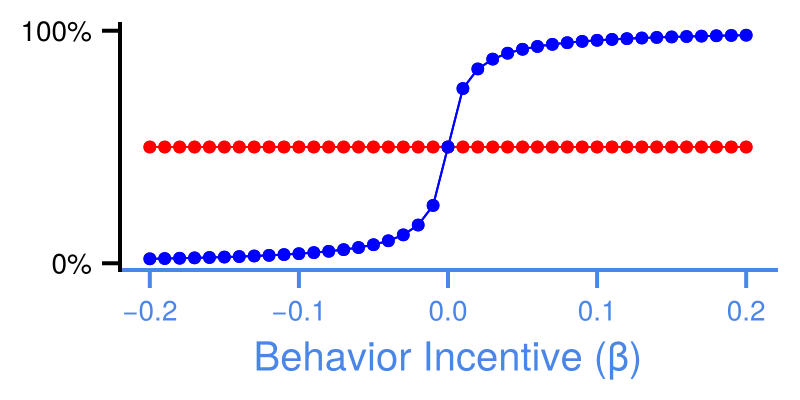

In [12]:
# Null + β equilibrium plot
αrange = [0.0]
βrange = range(-0.2,0.2,step=0.01)
λrange = [0.0]
timelimit = 5000

parameters = (
    alpha = 0.0,
    beta = 0.0,
    lambda = 0.0,
    ra = 1.0,
    rb = 1.0,
    H_strength = 1.0,
    epsilon = 0.01,
    S_sigmoid=false
)

eqsBehav, eqsAtt = getEquilibria(αrange,βrange,λrange,timelimit,parameters)

prob = ODEProblem(ODE!, u0, tspan, parameters)


# plot equilibria
fig, ax = blank_axis(xcolor = betaBlue,
    ycolor = :black,
    xlabel = "Behavior Incentive (β)",
    ylabel = "",#"Frequency \n of A+ and B+",
    yticks = ([0,1], ["0%", "100%"]), 
    size = eqPlotSize)

lines!(ax, βrange, eqsAtt[1,:,1,1]; color =:red, linewidth = 1)
lines!(ax, βrange, eqsAtt[1,:,1,2]; color =:red, linewidth = 1)
lines!(ax, βrange, eqsBehav[1,:,1,1]; color =:blue, linewidth = 1)
lines!(ax, βrange, eqsBehav[1,:,1,2]; color =:blue, linewidth = 1)

scatter!(ax, βrange, eqsAtt[1,:,1,1]; color =:red)
scatter!(ax, βrange, eqsAtt[1,:,1,2]; color =:red)
scatter!(ax, βrange, eqsBehav[1,:,1,1]; color =:blue)
scatter!(ax, βrange, eqsBehav[1,:,1,2]; color =:blue)

save("plots/Analytical/withAxes/1D eq β.png", fig)
fig

### Null + α equilibrium plot

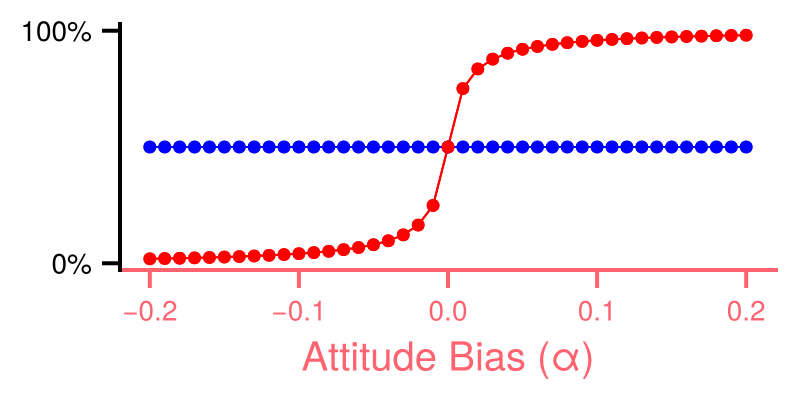

In [14]:
# Null + α equilibrium plot
αrange = range(-0.2,0.2,step=0.01)
βrange = [0.0]
λrange = [0.0]
timelimit = 5000

parameters = (
    alpha = 0.0,
    beta = 0.0,
    lambda = 0.0,
    ra = 1.0,
    rb = 1.0,
    H_strength = 1.0,
    epsilon = 0.01,
    S_sigmoid=false
)

eqsBehav, eqsAtt = getEquilibria(αrange,βrange,λrange,timelimit,parameters)

# plot equilibria
fig, ax = blank_axis(xcolor = alphaRed,
    ycolor = :black,
    xlabel = "Attitude Bias (α)",
    ylabel = "",#"Frequency \n of A+ and B+",
    yticks = ([0,1], ["0%", "100%"]), 
    size = eqPlotSize)

lines!(ax, αrange, eqsAtt[:,1,1,1]; color =:red, linewidth = 1)
lines!(ax, αrange, eqsAtt[:,1,1,2]; color =:red, linewidth = 1)
lines!(ax, αrange, eqsBehav[:,1,1,1]; color =:blue, linewidth = 1)
lines!(ax, αrange, eqsBehav[:,1,1,2]; color =:blue, linewidth = 1)

scatter!(ax, αrange, eqsBehav[:,1,1,1]; color =:blue)
scatter!(ax, αrange, eqsBehav[:,1,1,2]; color =:blue)
scatter!(ax, αrange, eqsAtt[:,1,1,1]; color =:red)
scatter!(ax, αrange, eqsAtt[:,1,1,2]; color =:red)

save("plots/Analytical/withAxes/1D eq α.png", fig)
fig

### Null + λ equilibrium plot

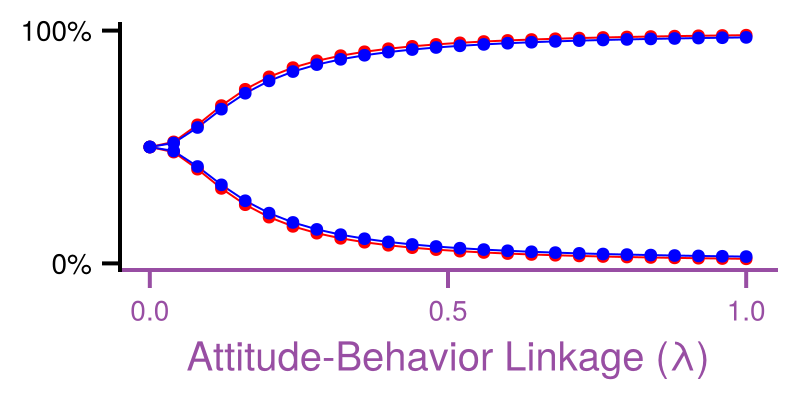

In [16]:
# Null + λ equilibrium plot
αrange = [0.0]
βrange = [0.0]
λrange = range(0,1.0,step=0.04)
timelimit = 5000

parameters = (
    alpha = 0.0,
    beta = 0.0,
    lambda = 0.0,
    ra = 1.0,
    rb = 1.0,
    H_strength = 1.0,
    epsilon = 0.01,
    S_sigmoid=false
)

eqsBehav, eqsAtt = getEquilibria(αrange,βrange,λrange,timelimit,parameters)

# plot equilibria
fig, ax = blank_axis(xcolor = lambdaPurple,
    ycolor = :black,
    xlabel = "Attitude-Behavior Linkage (λ)",
    ylabel = "",#"Frequency \n of A+ and B+",
    yticks = ([0,1], ["0%", "100%"]), 
    size = eqPlotSize)
#limits!(ax,0,1, 0, 1)

lines!(ax, λrange, eqsAtt[1,1,:,1]; color =:red, linewidth = 1)
lines!(ax, λrange, eqsAtt[1,1,:,2]; color =:red, linewidth = 1)
lines!(ax, λrange, eqsBehav[1,1,:,1]; color =:blue, linewidth = 1)
lines!(ax, λrange, eqsBehav[1,1,:,2]; color =:blue, linewidth = 1)


scatter!(ax, λrange, eqsAtt[1,1,:,1]; color =:red)
scatter!(ax, λrange, eqsAtt[1,1,:,2]; color =:red)
scatter!(ax, λrange, eqsBehav[1,1,:,1]; color =:blue)
scatter!(ax, λrange, eqsBehav[1,1,:,2]; color =:blue)

save("plots/Analytical/withAxes/1D eq λ.png", fig)
fig

### Null + β w/ λ=75% equilibrium plot

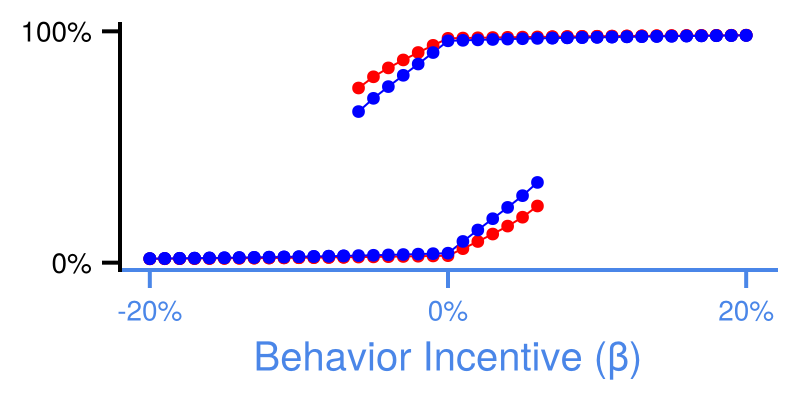

In [18]:
# Null + β with λ = 75% equilibrium plot SIGMOID
αrange = [0.0]
βrange = range(-0.2,0.2,step=0.01)
λrange = [0.75]
timelimit = 5000

parameters = (
    alpha = 0.0,
    beta = 0.0,
    lambda = 0.0,
    ra = 1.0,
    rb = 1.0,
    H_strength = 1.0,
    epsilon = 0.01,
    S_sigmoid=false
)

eqsBehav, eqsAtt = getEquilibria(αrange,βrange,λrange,timelimit,parameters)

# plot equilibria
xtickss=([βrange[1],0.0,βrange[end]],["$(round(Int,βrange[1]*100))%","0%","$(round(Int,βrange[end]*100))%"])
fig, ax = blank_axis(xcolor = betaBlue, ycolor = :black, xlabel = "Behavior Incentive (β)", xticks = xtickss, yticks = ([0,1], ["0%", "100%"]), size = eqPlotSize)

AttNeg = eqsAtt[1,:,1,1]
AttPos = eqsAtt[1,:,1,2]
BehavNeg = eqsBehav[1,:,1,1]
BehavPos = eqsBehav[1,:,1,2]

if true # separate high and low lines
    AttNeg[AttNeg .> 0.3] .= NaN
    AttPos[AttPos .< 0.5] .= NaN
    BehavNeg[BehavNeg .> 0.5] .= NaN
    BehavPos[BehavPos .< 0.5] .= NaN
end

lines!(ax, βrange, AttNeg; color =:red, linewidth = 1)
lines!(ax, βrange, AttPos; color =:red, linewidth = 1)
lines!(ax, βrange, BehavNeg; color =:blue, linewidth = 1)
lines!(ax, βrange, BehavPos; color =:blue, linewidth = 1)

scatter!(ax, βrange, eqsAtt[1,:,1,1]; color =:red)
scatter!(ax, βrange, eqsAtt[1,:,1,2]; color =:red)
scatter!(ax, βrange, eqsBehav[1,:,1,1]; color =:blue)
scatter!(ax, βrange, eqsBehav[1,:,1,2]; color =:blue)
save("plots/Analytical/withAxes/1D eq β with λ 75.png", fig)
fig

## 2D Equlibrium Plots

### Functions 
(run these first)

In [21]:
# functions (run these first)
function classifyCategoryNumber(eqPosStart,eqNegStart; closenessThresh = 0.01)
    
    if abs(eqPosStart - eqNegStart) > closenessThresh && eqPosStart > 0.5 && eqNegStart < 0.5
        return 2 #alternative stable states
    elseif eqPosStart < 0.5 - closenessThresh/2
        return 1 #neg only
    elseif eqNegStart > 0.5 + closenessThresh/2
        return 4 #pos only
    else
        return 3 # close to 50/50
    end
end

function getCategories(αrange,βrange,λrange,timelimit,params; closenessThresh = 0.01)

    # Initialize equilibrium arrays for plotting
    categoriesBehav = zeros(length(αrange),length(βrange),length(λrange))
    categoriesAtt = zeros(length(αrange),length(βrange),length(λrange))
    
    # go through all αrange,βrange,λrange values
    for (aa,αα) in enumerate(αrange),(bb,ββ) in enumerate(βrange),(ll,λλ) in enumerate(λrange)
        parameters = (
            alpha = αα,
            beta = ββ,
            lambda = λλ,
            ra = params.ra,
            rb = params.rb,
            H_strength = params.H_strength,
            epsilon = params.epsilon,
            S_sigmoid = params.S_sigmoid
        )
        
        tspan = (0.0, timelimit)

        # Start with all positive
        prob = ODEProblem(ODE!, [1.0,0,0,0], tspan, parameters)
        sol = solve(prob)
        APosStart = getindex.(sol.u, 1) +  getindex.(sol.u, 2)
        BPosStart = getindex.(sol.u, 1) +  getindex.(sol.u, 3)

        #start with all negative
        prob = ODEProblem(ODE!, [0,0,0,1.0], tspan, parameters)
        sol = solve(prob)
        ANegStart = getindex.(sol.u, 1) +  getindex.(sol.u, 2)
        BNegStart = getindex.(sol.u, 1) +  getindex.(sol.u, 3)

        #categorize and save
        categoriesAtt[aa,bb,ll] = classifyCategoryNumber(APosStart[end],ANegStart[end], closenessThresh = closenessThresh)
        categoriesBehav[aa,bb,ll] = classifyCategoryNumber(BPosStart[end],BNegStart[end], closenessThresh = closenessThresh)
    end
    return categoriesBehav, categoriesAtt
end;

### β vs λ map
Fig S4C, S5B: set αrange = [0.0]

Fig S5A: set αrange = [-0.1]

Fig S5C: set αrange = [0.1]

Fig S5D: set αrange = [0.2]

In [23]:
# β vs λ

# run simulations
αrange = [0.0]
βrange = range(-0.3,0.3,step=0.002)
λrange = range(0,1.0,step=0.002)
timelimit = 5000

parameters = (
    alpha = 0.0,
    beta = 0.0,
    lambda = 0.0,
    ra = 1.0,
    rb = 1.0,
    H_strength = 1.0,
    epsilon = 0.01,
    S_sigmoid=false
)

categoriesBehav, categoriesAtt = getCategories(αrange, βrange, λrange, timelimit, parameters)

categories = categoriesBehav[1,:,:];

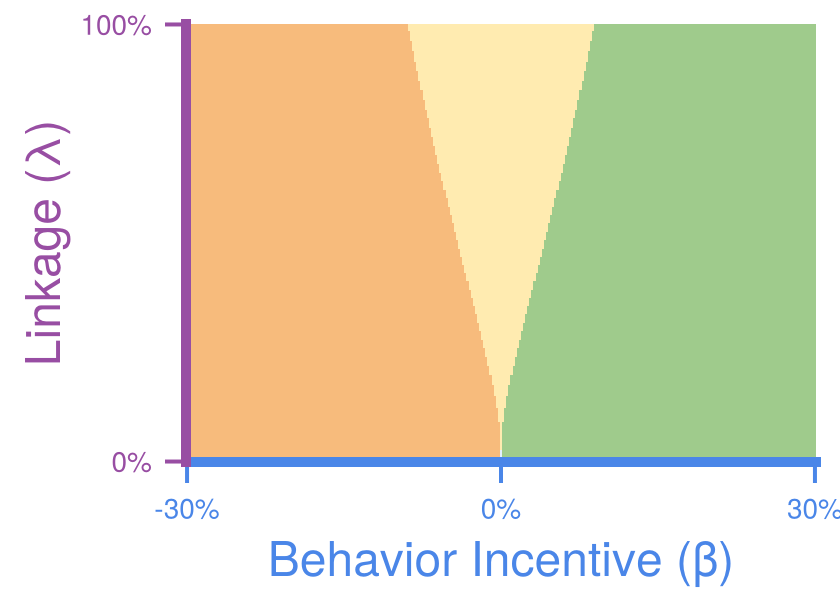

In [24]:
# Plot beta as x axis lambda as y axis

xtickss=([1,findfirst(βrange.==0.0),length(βrange)],["$(round(Int,βrange[1]*100))%","0%","$(round(Int,βrange[end]*100))%"])

fig, ax = blank_axis(
    xcolor = betaBlue, 
    ycolor = lambdaPurple, 
    yticks=([1,length(λrange)],["0%","100%"]), 
    xticks=xtickss ,xlabel = "Behavior Incentive (β)",
    ylabel = "Linkage (λ)",
    xaxiswidth=5,
    yaxiswidth=5,
    ylabelsize=24,
    xlabelsize=24,
    size = (420,300))

heatmap!(ax,categories;colormap=[negOnly,inducible,sponBoth,posOnly],colorrange=(1, 4), interpolate=false)
save("plots/Analytical/withAxes/2D β v λ with α $αrange (fig 7 version).png", fig)
fig

### β vs α map

Fig S5F: set λrange = [0.9]

Fig S5G: set λrange = [0.1]

In [26]:
# β vs α
# run simulations
αrange = range(-0.5,0.5,step=0.005)
βrange = range(-0.5,0.5,step=0.005)
λrange = [0.9]
timelimit = 5000

parameters = (
    alpha = 0.0,
    beta = 0.0,
    lambda = 0.0,
    ra = 1.0,
    rb = 1.0,
    H_strength = 1.0,
    epsilon = 0.01,
    S_sigmoid=false
)

categoriesBehav, categoriesAtt = getCategories(αrange, βrange, λrange, timelimit, parameters)

categories = transpose(categoriesBehav[:,:,1]);

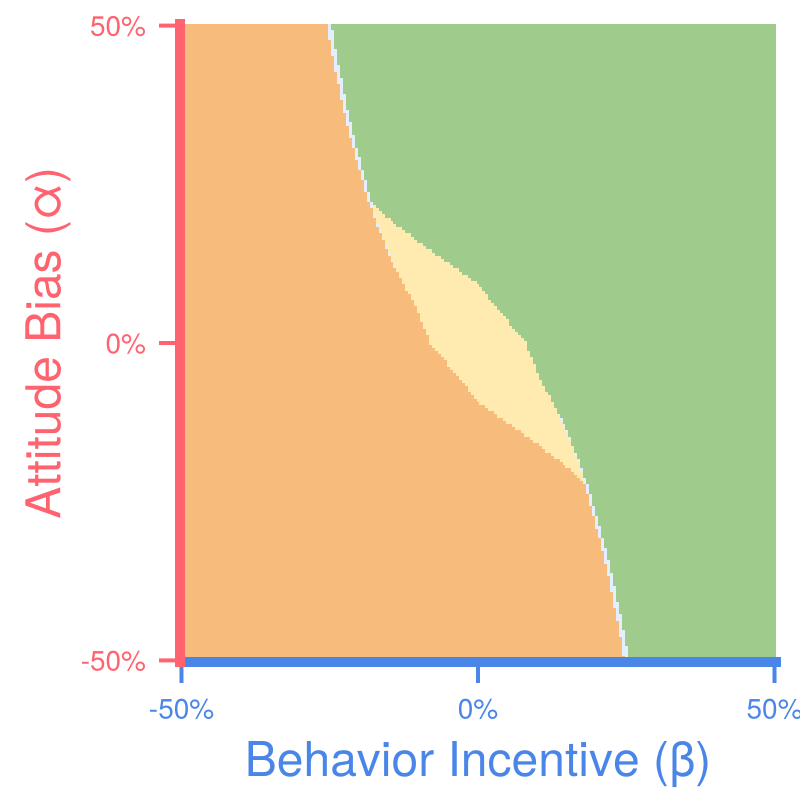

In [27]:
# Plot beta as x axis alpha as y axis

xtickss=([1,findfirst(βrange.==0.0),length(βrange)],["$(round(Int,βrange[1]*100))%","0%","$(round(Int,βrange[end]*100))%"])
ytickss=([1,findfirst(αrange.==0.0),length(αrange)],["$(round(Int,αrange[1]*100))%","0%","$(round(Int,αrange[end]*100))%"])

fig, ax = blank_axis(xcolor = betaBlue,
    ycolor = alphaRed,
    yticks=ytickss,
    xticks=xtickss,
    xlabel = "Behavior Incentive (β)",
    ylabel = "Attitude Bias (α)",
    xaxiswidth=5,
    yaxiswidth=5,
    ylabelsize=24,
    xlabelsize=24,
    size = (400,400))



heatmap!(ax,categories;colormap=[negOnly,inducible,sponBoth,posOnly],colorrange=(1, 4), interpolate=false)
save("plots/Analytical/withAxes/2D β v α with λ $λrange.png", fig)
fig

### α vs λ map
Fig S10C

In [29]:
# α vs λ
# run sims

αrange = range(-0.3,0.3,step=0.002)
βrange = [0.0]
λrange = range(0,1.0,step=0.002)
timelimit = 5000

parameters = (
    alpha = 0.0,
    beta = 0.0,
    lambda = 0.0,
    ra = 1.0,
    rb = 1.0,
    H_strength = 1.0,
    epsilon = 0.01,
    S_sigmoid = false
)

categoriesBehav, categoriesAtt = getCategories(αrange, βrange, λrange, timelimit, parameters)

categories = categoriesBehav[:,1,:];

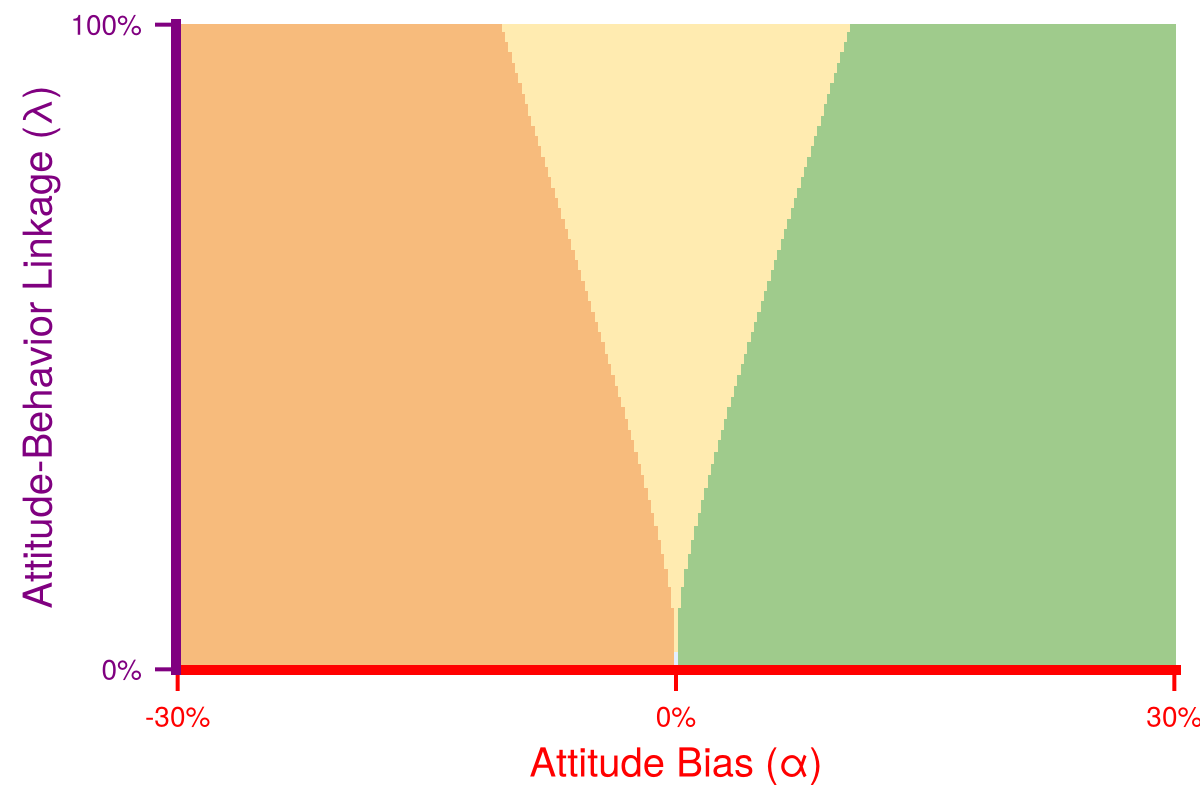

In [30]:
# Plot alpha as x axis lambda as y axis

negOnly = "#f7bb7cff"  #"#f7bb7cff"
posOnly = "#9fcb8cff"  #"#9fcb8cff"
sponBoth = "#bddaff6d"
inducible = "#ffebb0ff"#"#a8b7e0ff"
nodata="#00000000"

xtickss=([1,findfirst(αrange.==0.0),length(αrange)],["$(round(Int,αrange[1]*100))%","0%","$(round(Int,αrange[end]*100))%"])

fig, ax = blank_axis(xcolor = :red, ycolor = :purple, yticks=([1,length(λrange)],["0%","100%"]), xticks=xtickss ,xlabel = "Attitude Bias (α)", ylabel = "Attitude-Behavior Linkage (λ)", xaxiswidth=5, yaxiswidth=5,size = (600,400))

heatmap!(ax,categories;colormap=[negOnly,inducible,sponBoth,posOnly],colorrange=(1, 4), interpolate=false)
save("plots/Analytical/withAxes/2D α v λ.png", fig)
fig

## Supplemental 2D Basins of attraction plots

Fig S9

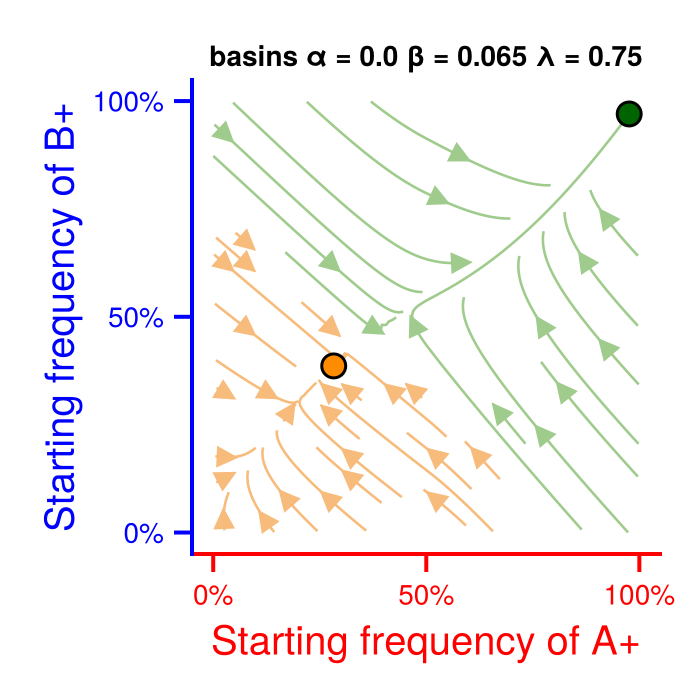

In [32]:
alpha = 0.0
beta = 0.065
lambda = 0.75

parameters = (
    alpha = alpha,
    beta = beta,
    lambda = lambda,
    ra = 1.0,
    rb = 1.0,
    H_strength = 1.0,
    epsilon = 0.01,
    S_sigmoid = false
)


Ap_starts = range(0,1.0,step=0.01)
Bp_starts = range(0,1.0,step=0.01)

xtickss = ([0.0, 0.5, 1.0], ["0%", "50%", "100%"])
ytickss = ([0.0, 0.5, 1.0], ["0%", "50%", "100%"])
# plot equilibria
fig, ax = blank_axis(xcolor = :red,
    ycolor = :blue,
    xlabel = "Starting frequency of A+",
    ylabel = "Starting frequency of B+",
    title = "basins α = $alpha β = $beta λ = $lambda",
    xticks = xtickss,
    yticks = ytickss,
    padding = 20,
    size = (350,350))



BehavOutcomes = zeros(length(Ap_starts),length(Bp_starts))
AttOutcomes = zeros(length(Ap_starts),length(Bp_starts))

for (ai, aa) in enumerate(Ap_starts), (bi, bb) in enumerate(Bp_starts)
        tspan = (0.0, timelimit)
        u0 = [aa,bb]
        prob = ODEProblem(ODEposneg!, u0, tspan, parameters)
        sol = solve(prob)
        getindex.(sol.u, 1)
        AttOutcomes[ai,bi] = getindex.(sol.u, 1)[end]
        BehavOutcomes[ai,bi] = getindex.(sol.u, 2)[end]
end

function basin_id(x, y, BehavOutcomes, Ap_starts, Bp_starts)
    i = clamp(searchsortedfirst(Ap_starts, x), 1, length(Ap_starts))
    j = clamp(searchsortedfirst(Bp_starts, y), 1, length(Bp_starts))
    return BehavOutcomes[i, j] >= 0.5 ? 1 : 0   # 1 = green basin, 0 = orange basin
end

function vf_green(x, p, BehavOutcomes, Ap_starts, Bp_starts)
    bx = clamp(x[1], 0, 1)
    by = clamp(x[2], 0, 1)

    if basin_id(bx, by, BehavOutcomes, Ap_starts, Bp_starts) == 1
        return vf(Point2f(bx, by), p)
    else
        return Vec2f(0, 0)
    end
end

function vf_orange(x, p, BehavOutcomes, Ap_starts, Bp_starts)
    bx = clamp(x[1], 0, 1)
    by = clamp(x[2], 0, 1)

    if basin_id(bx, by, BehavOutcomes, Ap_starts, Bp_starts) == 0
        return vf(Point2f(bx, by), p)
    else
        return Vec2f(0, 0)
    end
end

gridsize = (20,20)
density = 0.5
linewidth = 1.3

streamplot!(
    ax,
    x -> vf_orange(x, parameters, BehavOutcomes, Ap_starts, Bp_starts),
    0..1, 0..1;
    gridsize = gridsize,
    density = density,
    linewidth = linewidth,
    color = _ -> negOnly
)

streamplot!(
    ax,
    x -> vf_green(x, parameters, BehavOutcomes, Ap_starts, Bp_starts),
    0..1, 0..1;
    gridsize = gridsize,
    density = density,
    linewidth = linewidth,
    color = _ -> posOnly
)

tspan = (0.0, timelimit)
u0 = [0,0]
prob = ODEProblem(ODEposneg!, u0, tspan, parameters)
sol = solve(prob)
scatter!(ax, getindex.(sol.u, 1)[end], getindex.(sol.u, 2)[end]; color = :darkOrange, markersize=17, strokecolor = :black, strokewidth = 1.5)

tspan = (0.0, timelimit)
u0 = [1,1]
prob = ODEProblem(ODEposneg!, u0, tspan, parameters)
sol = solve(prob)
scatter!(ax, getindex.(sol.u, 1)[end], getindex.(sol.u, 2)[end]; color = :darkgreen, markersize=17, strokecolor = :black, strokewidth = 1.5)


save("plots/Analytical/withAxes/basins with arrows α = $alpha β = $beta λ = $lambda.png", fig)
fig